In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\MOHANASUNDARAM.M\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf

In [4]:
print(tf.__version__)

2.21.0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset = pd.read_csv('churn_modeling_dataset.csv')

In [7]:
dataset.head()

,CustomerID,Age,Gender,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,1,56,Male,16,196568.99,4,1,1,69925.54,0
1,2,69,Male,49,143646.85,1,1,1,106614.82,1
2,3,46,Male,39,141643.84,3,0,1,148548.62,0
3,4,32,Female,44,97760.69,1,0,0,49344.60,0
4,5,60,Male,31,125288.25,1,0,0,70686.97,0


# # Divide the dataset into independent and dependent features

In [11]:
X = dataset.iloc[:, :-1]   # all columns except last
y = dataset.iloc[:, -1]    # last column (Churn)

In [12]:
X

,CustomerID,Age,Gender,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary
0,1,56,Male,16,196568.99,4,1,1,69925.54
1,2,69,Male,49,143646.85,1,1,1,106614.82
2,3,46,Male,39,141643.84,3,0,1,148548.62
3,4,32,Female,44,97760.69,1,0,0,49344.60
4,5,60,Male,31,125288.25,1,0,0,70686.97
...,...,...,...,...,...,...,...,...,...
995,996,60,Female,3,179913.45,3,1,0,68489.98
996,997,64,Male,17,92790.40,2,1,0,47174.81
997,998,62,Female,54,217440.79,1,0,1,110453.35
998,999,35,Male,5,182624.09,1,0,0,142747.15


In [13]:
y

0      0
1      1
2      0
3      0
4      0
      ..
995    1
996    0
997    1
998    0
999    0
Name: Churn, Length: 1000, dtype: int64

# Feature handling

In [ ]:
# geography = pd.get_dummies([''])

In [30]:
gender = pd.get_dummies(['Gender'],drop_first=True)

In [31]:
gender

""
0


In [16]:
## concatenate these variables with dataFrame

In [32]:
# axis =1 means droping the columns ,axis = 0 means dropping the rows
X.drop(['Gender'],axis=1)

KeyError: "['Gender'] not found in axis"

In [33]:
    X = pd.concat([X,gender],axis=1)

In [34]:
X

,CustomerID,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Gender_Male
0,1,56,16,196568.99,4,1,1,69925.54,True
1,2,69,49,143646.85,1,1,1,106614.82,True
2,3,46,39,141643.84,3,0,1,148548.62,True
3,4,32,44,97760.69,1,0,0,49344.60,False
4,5,60,31,125288.25,1,0,0,70686.97,True
...,...,...,...,...,...,...,...,...,...
995,996,60,3,179913.45,3,1,0,68489.98,False
996,997,64,17,92790.40,2,1,0,47174.81,True
997,998,62,54,217440.79,1,0,1,110453.35,False
998,999,35,5,182624.09,1,0,0,142747.15,True


In [35]:
# Splitting the dataset into Training set and Test set
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

KeyError: "None of [Index(['Gender'], dtype='object')] are in the [columns]"

In [23]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

# Interview Question: For which all algorithms features scaling is required?
# For ANN?  LR is required or Logistice Reg is required or Descion tree is Required or Random forest is required??
- LR ans Log R is required

## Feature scaling

In [26]:
from sklearn.preprocessing import StandardScaler

In [29]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

ValueError: could not convert string to float: 'Male'

In [36]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

# Step 2: Load dataset
dataset = pd.read_csv('churn_modeling_dataset.csv')

# Step 3: Separate features and target
X = dataset.iloc[:, 1:-1]   # remove CustomerID + target
y = dataset.iloc[:, -1]

# Step 4: Convert categorical data (Gender)
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Step 5: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [37]:
X_train

array([[-0.12149869,  0.74665904,  1.57581523, ..., -1.05131497,
        -0.19212338, -1.06191317],
       [-1.4818759 , -1.47215179, -0.39683125, ..., -1.05131497,
        -0.22719504,  0.94169658],
       [ 1.4429351 , -1.06342348,  1.14832933, ...,  0.95118973,
         0.17393534, -1.06191317],
       ...,
       [ 0.49067105, -1.12181324,  0.51097633, ..., -1.05131497,
        -0.75199685, -1.06191317],
       [ 1.30689738,  1.03860783, -0.63603725, ...,  0.95118973,
        -0.28838631, -1.06191317],
       [-0.12149869, -1.06342348,  1.27142488, ...,  0.95118973,
         0.47089384,  0.94169658]], shape=(800, 8))

In [39]:
X_test

array([[-1.4818759 , -0.94664396, -0.30463934, ..., -1.05131497,
        -1.2141948 ,  0.94169658],
       [ 0.35463333,  1.33055663, -1.69159107, ..., -1.05131497,
         1.28011363,  0.94169658],
       [-0.39357413, -0.1875771 ,  0.34354084, ..., -1.05131497,
         1.15273244, -1.06191317],
       ...,
       [ 1.17085966, -1.58893131,  1.61840585, ..., -1.05131497,
        -0.8248095 ,  0.94169658],
       [ 1.51095396,  1.03860783, -0.0815687 , ..., -1.05131497,
        -1.43569622, -1.06191317],
       [-1.14178159,  1.03860783, -1.10386864, ...,  0.95118973,
         0.51158664, -1.06191317]], shape=(200, 8))

In [40]:
X_train.shape

(800, 8)

### ----------------------------------------------------------------------------

# create a ANN

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout
import tensorflow.keras

In [45]:
### Lets intialize the ANN
classifier = Sequential()

In [46]:
## ADding the input Layer
classifier.add(Dense(units=11,activation='relu'))

In [47]:
## Adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [48]:
## Adding the Second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [49]:
## Adding the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [53]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [52]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [54]:
# Train
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000)

Epoch 1/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4478 - loss: 0.7064 - val_accuracy: 0.5189 - val_loss: 0.6944
Epoch 2/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5205 - loss: 0.6936 - val_accuracy: 0.4621 - val_loss: 0.6980
Epoch 3/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5037 - loss: 0.6925 - val_accuracy: 0.4848 - val_loss: 0.6989
Epoch 4/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5448 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.7023
Epoch 5/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5522 - loss: 0.6914 - val_accuracy: 0.5038 - val_loss: 0.7030
Epoch 6/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5336 - loss: 0.6902 - val_accuracy: 0.5303 - val_loss: 0.7010
Epoch 7/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5522 - loss: 0.6861 - val_accuracy: 0.5114 - val_loss: 0.7038
Epoch 8/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5672 - loss: 0.6815 - val_accuracy: 0

KeyboardInterrupt: 

In [60]:
# early stopping
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    restore_best_weights=True
)

In [61]:
# Train
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7854 - loss: 0.3674 - val_accuracy: 0.4583 - val_loss: 2.4940
Epoch 2/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7761 - loss: 0.3774 - val_accuracy: 0.4697 - val_loss: 2.5832
Epoch 3/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7631 - loss: 0.4138 - val_accuracy: 0.4583 - val_loss: 2.5273
Epoch 4/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7313 - loss: 0.4740 - val_accuracy: 0.4886 - val_loss: 2.3674
Epoch 5/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7369 - loss: 0.4315 - val_accuracy: 0.5000 - val_loss: 2.7352
Epoch 6/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7332 - loss: 0.4642 - val_accuracy: 0.5000 - val_loss: 2.2403
Epoch 7/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7332 - loss: 0.4216 - val_accuracy: 0.5455 - val_loss: 2.2819
Epoch 8/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7873 - loss: 0.4029 - val_accuracy: 0.

In [62]:
model_history

In [65]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

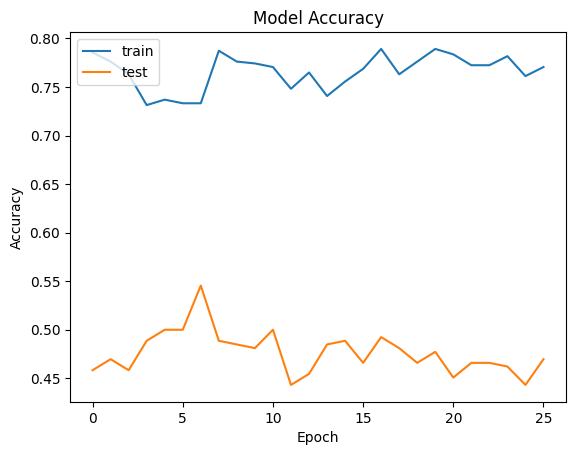

In [68]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])

plt.title('Model Accuracy')   
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['train', 'test'], loc='upper left')

plt.show()

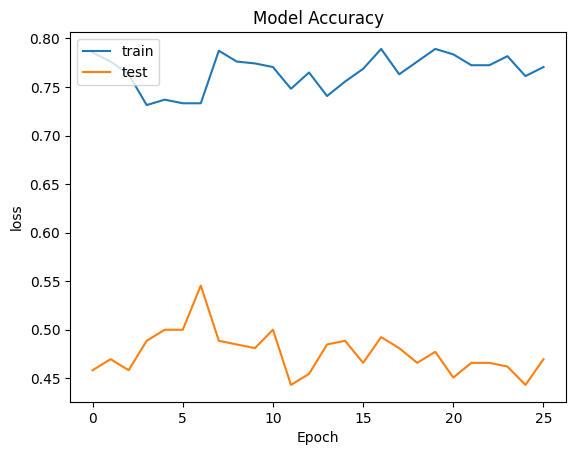

In [69]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])

plt.title('Model Accuracy')   
plt.ylabel('loss')
plt.xlabel('Epoch')

plt.legend(['train', 'test'], loc='upper left')

plt.show()

### Making the predcition and evaluting the model

In [70]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


# Make the Confusion matrix


In [71]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[48, 54],
       [44, 54]])

# Calculate the Accuracy

In [72]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)

In [73]:
score

0.51

# Get the weights

In [75]:
classifier.get_weights()

[array([[-1.5759312 , -0.05310808,  0.9497498 , -0.3324716 ,  1.6537198 ,
         -1.2878739 ,  1.9298534 , -1.6376519 , -0.58497757,  2.6165547 ,
          0.51861495],
        [ 1.3648385 , -0.39955977, -1.1648165 ,  1.2519675 , -0.9925374 ,
         -1.0043306 , -0.40030047, -1.1021972 ,  0.6683262 , -0.33742905,
          2.184441  ],
        [-1.3964071 ,  0.6912673 , -1.4573987 ,  2.3061302 ,  0.13125555,
          0.6914175 ,  0.17410594, -0.16775186, -0.2875088 ,  0.27593666,
          0.6302972 ],
        [-2.1251578 , -0.72272885,  1.2424432 , -0.03328413, -0.9081734 ,
          1.5404903 , -0.96974313, -1.4998916 , -1.2541072 ,  0.06806836,
          1.3727933 ],
        [ 1.681587  ,  1.8267529 ,  0.1672092 , -0.7355377 ,  1.0780495 ,
          1.1837218 , -1.2429053 , -0.06131633, -1.4112211 , -0.19693184,
          0.87151873],
        [-1.3985287 , -2.062329  , -0.38624918,  0.5667606 ,  2.1896667 ,
          0.51247627, -0.20619154,  0.6664154 ,  1.1969833 ,  2.2472959

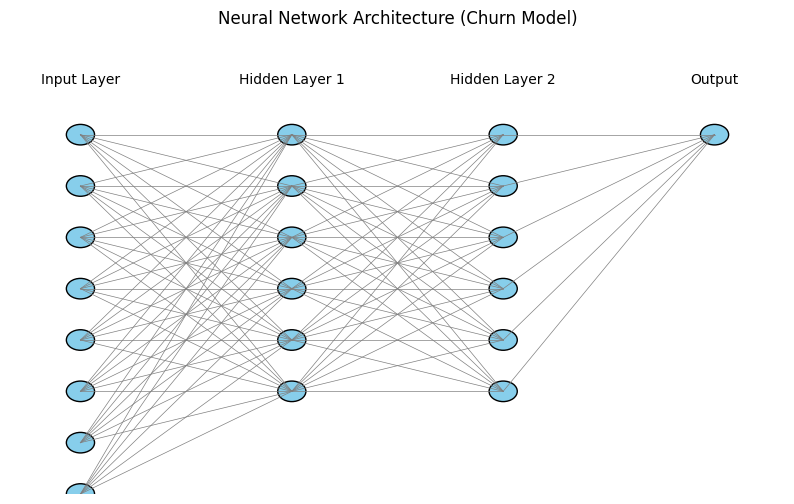

In [76]:
import matplotlib.pyplot as plt

# Function to draw a layer
def draw_layer(ax, x, y, n_nodes, label):
    for i in range(n_nodes):
        circle = plt.Circle((x, y - i), 0.2, color='skyblue', ec='black')
        ax.add_patch(circle)
    ax.text(x, y + 1, label, ha='center', fontsize=10)

# Function to connect layers
def connect_layers(ax, x1, y1, n1, x2, y2, n2):
    for i in range(n1):
        for j in range(n2):
            ax.plot([x1, x2], [y1 - i, y2 - j], 'gray', linewidth=0.5)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define layers (based on your model)
input_nodes = 8        # features after encoding
hidden1_nodes = 6
hidden2_nodes = 6
output_nodes = 1

# Draw layers
draw_layer(ax, 0, 4, input_nodes, "Input Layer")
draw_layer(ax, 3, 4, hidden1_nodes, "Hidden Layer 1")
draw_layer(ax, 6, 4, hidden2_nodes, "Hidden Layer 2")
draw_layer(ax, 9, 4, output_nodes, "Output")

# Connect layers
connect_layers(ax, 0, 4, input_nodes, 3, 4, hidden1_nodes)
connect_layers(ax, 3, 4, hidden1_nodes, 6, 4, hidden2_nodes)
connect_layers(ax, 6, 4, hidden2_nodes, 9, 4, output_nodes)

# Final touches
ax.set_xlim(-1, 10)
ax.set_ylim(-3, 6)
ax.axis('off')

plt.title("Neural Network Architecture (Churn Model)")
plt.show()

# THE END!!